# Implement and test the Milstein scheme

---

a.) Implement the Milstein scheme in the MCMethod class' evolve_simulated_spot method, test it by pricing an option with it and compare the PV with analytic.

b.) Compare the strong convergence of Euler and Milstein methods as we reduce the size of timesteps.

---

The strong convergence error with timestep dt is measured as the expected pathwise abolute error at time T between the approximation and exact solution:
$$ ϵ^{\text{strong(dt)}} = E[|S^{\text{approx}, dt}(T) − S^{exact}(T)|] $$


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

_cwd = Path.cwd()
_assignment_root = _cwd if (_cwd / "src").exists() else _cwd / "homeworks" / "Assignment 6"
if (_assignment_root / "src").exists() and str(_assignment_root) not in sys.path:
    sys.path.insert(0, str(_assignment_root))

from src.market_data import MarketData
from src.enums import Stock, PutCallFwd, LongShort, MCNumMethod
from src.contract import EuropeanContract
from src.model import FlatVolModel
from src.numerical_method import MCMethodFlatVol, MCParams

In [4]:
MarketData.initialize()

und = Stock.TEST_COMPANY
spot = MarketData.get_spot()[und]
rate = MarketData.get_risk_free_rate()
strike = spot  # ATM
expiry = 1.0

contract = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, expiry)
model = FlatVolModel(und)
vol = model.get_vol(strike, expiry)

In [5]:
spot

np.float64(100.0)

In [6]:
rate

0.05

In [7]:
vol

np.float64(0.3)

## a.)

In [8]:
from scipy.stats import norm


def bs_call(S, K, T, r, v):
    d1 = (np.log(S / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


analytic = bs_call(spot, strike, expiry, rate, vol)
print("Analytic BS price:", analytic)

Analytic BS price: 14.231254785985819


In [10]:
base_params = dict(
    seed=476,
    num_of_path=50000,
    tenor_frequency=52,  # weekly step count
    standardize=False,
    antithetic=False,
    control_variate=False,
)
for method in [MCNumMethod.MILSTEIN, MCNumMethod.EXACT, MCNumMethod.EULER]:
    params = MCParams(**base_params, evolve_spot_method=method)
    mc = MCMethodFlatVol(contract, model, params)
    
    spot_paths = mc.simulate_spot_paths()
    
    S_T = spot_paths[:, -1]
    
    payoffs = np.maximum(S_T - strike, 0.0)
    discount = np.exp(-rate * expiry)
    pv = discount * np.mean(payoffs)
    se = discount * np.std(payoffs, ddof=1) / np.sqrt(len(payoffs))
    
    print(f"{method.value:<10} \t MC price: {pv} (pm {1.96 * se} 95% CI)")


MILSTEIN   	 MC price: 14.18598172099394 (pm 0.19568483024186598 95% CI)
EXACT      	 MC price: 14.198365550024128 (pm 0.19590264751945305 95% CI)
EULER      	 MC price: 14.202115121599748 (pm 0.19517273182260567 95% CI)


## b.)

In [11]:
NUM_PATHS = 10000
MAX_STEPS = 1024
STEPS_LIST = [4, 8, 16, 32, 64, 128, 256, 512]

fine_dt = expiry / MAX_STEPS
dW_fine = np.random.standard_normal((NUM_PATHS, MAX_STEPS)) * np.sqrt(fine_dt)

# Exact solution
W_T = dW_fine.sum(axis=1) # shape (NUM_PATHS,)
S_exact = spot * np.exp((rate - 0.5 * vol**2) * expiry + vol * W_T)

In [21]:
euler_errors = []
milstein_errors = []

for num_steps in STEPS_LIST:
    factor = MAX_STEPS // num_steps
    dW = dW_fine.reshape(NUM_PATHS, num_steps, factor).sum(axis=2)
    dt = expiry / num_steps

    S_euler = np.full(NUM_PATHS, float(spot))
    S_milstein = np.full(NUM_PATHS, float(spot))

    for step in range(num_steps):
        dw = dW[:, step]
        S_euler = S_euler + rate * S_euler * dt + vol * S_euler * dw
        correction = 0.5 * vol**2 * S_milstein * (dw**2 - dt)
        S_milstein = S_milstein + rate * S_milstein * dt + vol * S_milstein * dw + correction

    euler_errors.append(np.mean(np.abs(S_euler - S_exact)))
    milstein_errors.append(np.mean(np.abs(S_milstein - S_exact)))
    
    print(
        f"Step: {num_steps} \t dt={dt:<15} \t Euler={euler_errors[-1]:<20} \t Milstein={milstein_errors[-1]:<10}"
    )


Step: 4 	 dt=0.25            	 Euler=2.5668879459166947   	 Milstein=0.3070405352212598
Step: 8 	 dt=0.125           	 Euler=1.8699585000714725   	 Milstein=0.1690725618337342
Step: 16 	 dt=0.0625          	 Euler=1.3310760561168844   	 Milstein=0.09067012494063773
Step: 32 	 dt=0.03125         	 Euler=0.9390851162556906   	 Milstein=0.04714688394463594
Step: 64 	 dt=0.015625        	 Euler=0.6677101990490959   	 Milstein=0.02406961581248404
Step: 128 	 dt=0.0078125       	 Euler=0.4678334396975403   	 Milstein=0.011981664877134975
Step: 256 	 dt=0.00390625      	 Euler=0.33384145074780697  	 Milstein=0.006046497871284912
Step: 512 	 dt=0.001953125     	 Euler=0.23185819692504966  	 Milstein=0.0030098770703592416


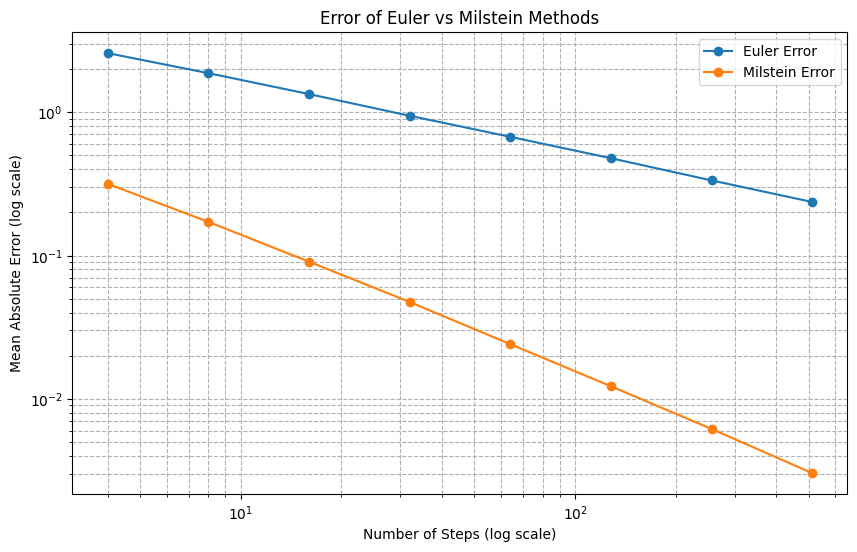

In [22]:
# Plotting errors
plt.figure(figsize=(10, 6))
plt.loglog(STEPS_LIST, euler_errors, marker='o', label='Euler Error')
plt.loglog(STEPS_LIST, milstein_errors, marker='o', label='Milstein Error')
plt.xlabel('Number of Steps (log scale)')
plt.ylabel('Mean Absolute Error (log scale)')
plt.title('Error of Euler vs Milstein Methods') 
plt.legend()
plt.grid(True, which="both", ls="--")
# plt.tight_layout()
plt.show()

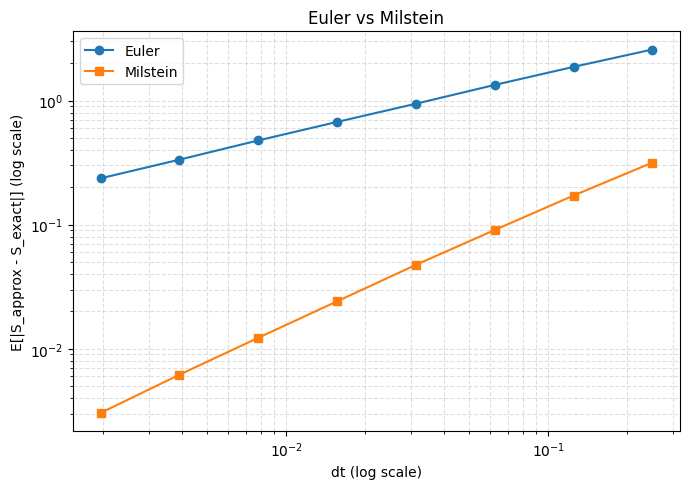

In [24]:
dts = np.array([expiry / n for n in STEPS_LIST])

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dts, euler_errors, "o-", label="Euler")
ax.loglog(dts, milstein_errors, "s-", label="Milstein")

ax.set_xlabel("dt (log scale)")
ax.set_ylabel("E[|S_approx - S_exact|] (log scale)")
ax.set_title("Euler vs Milstein")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## AI Usage

- Claude Sonnet 4.6 Adaptive thinking: dimensionality fixes.
- GitHub Copilot - GPT-5.4-mini - Agentic: Fixing import pathing issues.